In [1]:
import pathlib
import numpy as np
import pandas as pd

import Bio
import Bio.Seq
import Bio.SeqIO


from scipy.stats import poisson

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

import seaborn as sns

## Get CCS Read data and create summary statistics

In [2]:
!pwd

/Users/brycejohnson/Desktop/proteins/sadx-latent-function/scripts/process_sequence_data


In [3]:
data_dir = pathlib.Path("../../data/Oct22")
figs_dir = pathlib.Path("../../output/process_seq_data")

In [4]:
samples = pd.read_csv(data_dir / "Samples.csv")
samples[["parent", "category"]] = samples["sample"].str.split("_", expand=True)
samples["frac_kept"] = samples.num_kept / samples.num_seqs
samples.set_index("barcode", inplace=True)
samples

,sample,num_placed,num_seqs,num_kept,align_filter,length_filter,quality_filter,parent,category,frac_kept
barcode,,,,,,,,,,
bcAd1036T,1VH_H,4,127801,75214,101908,99932,75214,1VH,H,0.588524
bcAd1037T,1VH_P,2,91298,29062,41772,38552,29062,1VH,P,0.318320
bcAd1039T,1VH_L,349,159287,77991,109574,105660,77991,1VH,L,0.489626
bcAd1040T,1VH_N,454,117798,40370,62755,54346,40370,1VH,N,0.342705
bcAd1043T,2L_H,29,89971,42280,64424,59930,42280,2L,H,0.469929
bcAd1044T,2L_P,52,33222,14146,22144,20246,14146,2L,P,0.425802
bcAd1045T,2L_L,532,170155,67602,98802,94426,67602,2L,L,0.397297
bcAd1046T,2L_N,287,143675,43242,62543,60169,43242,2L,N,0.300971
bcAd1047T,3VRL_H,81,87753,47470,68389,63481,47470,3VRL,H,0.540950


In [5]:
samples_melt = pd.melt(samples, id_vars=["parent", "category"], 
        value_vars=["num_seqs", "align_filter", "length_filter", "quality_filter"])

/Users/brycejohnson/anaconda3/envs/rtl/lib/python3.9/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


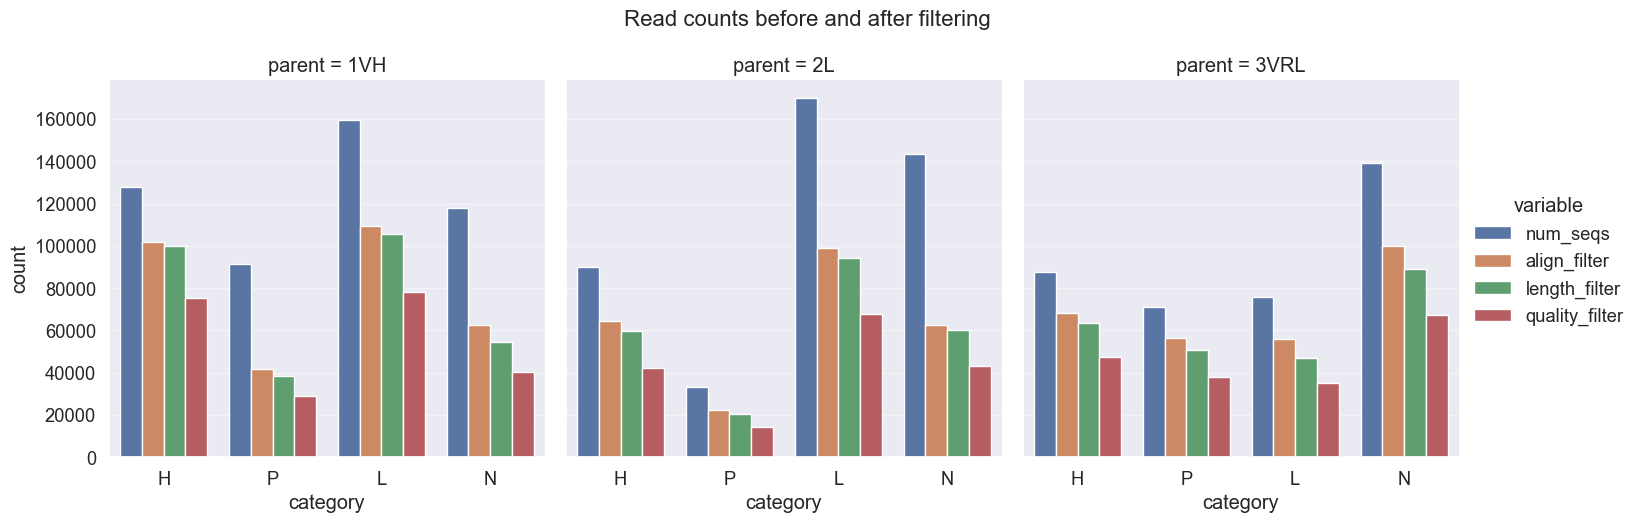

In [6]:
sns.set(font_scale=1.2)

g = sns.catplot(data=samples_melt, x="category", y="value", hue="variable",
            col="parent", kind="bar")

g.fig.suptitle("Read counts before and after filtering", size=16, y=1.05)
g.axes[0,0].set_ylabel("count")
plt.savefig(figs_dir / "Raw Read Counts.png", dpi=300)

pass

/Users/brycejohnson/anaconda3/envs/rtl/lib/python3.9/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


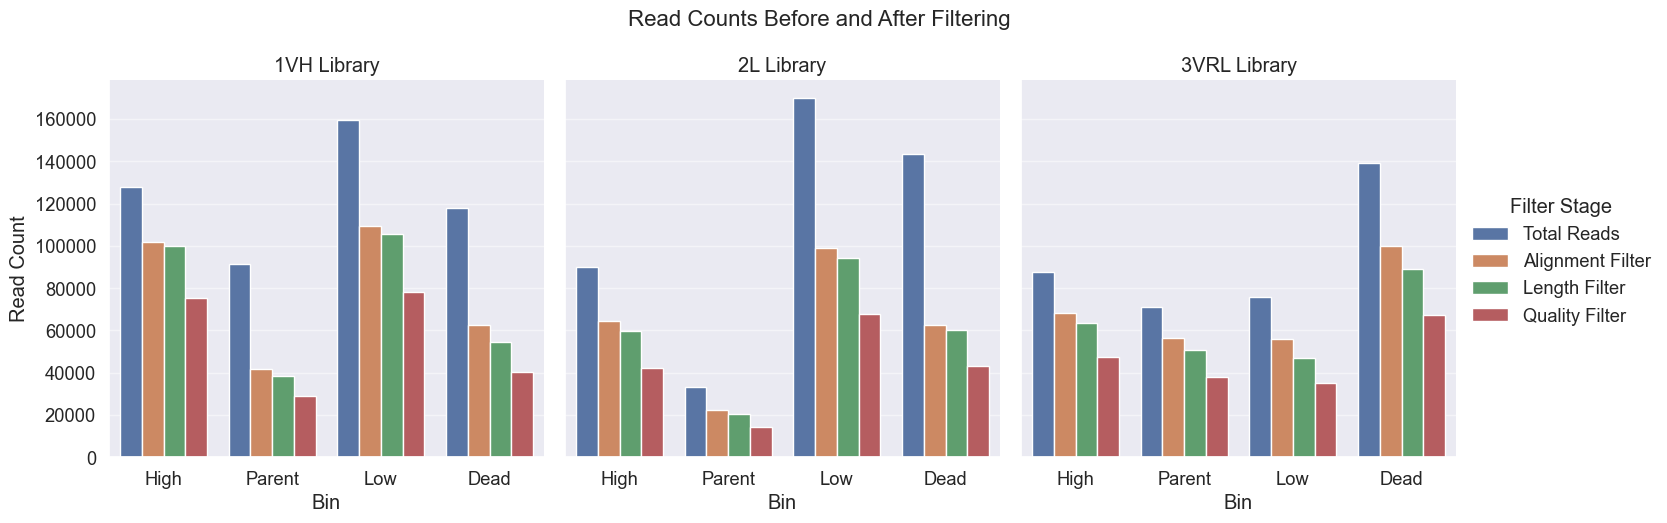

In [7]:
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['font.family'] = 'Times New Roman'
matplotlib.rcParams['svg.fonttype'] = 'path'


sns.set(font_scale=1.2)

# Clean up legend labels
var_map = {
    "num_seqs": "Total Reads",
    "align_filter": "Alignment Filter",
    "length_filter": "Length Filter",
    "quality_filter": "Quality Filter",
}
samples_melt["Filter Stage"] = samples_melt["variable"].map(var_map).fillna(samples_melt["variable"])

# Clean up bin labels
bin_map = {"H": "High", "P": "Parent", "N": "Dead", "L": "Low"}
samples_melt["Bin"] = samples_melt["category"].map(bin_map).fillna(samples_melt["category"])

# Clean up parent/library labels for facet titles
parent_map = {"1vh": "1VH", "2l": "2L", "3vrl": "3VRL"}
samples_melt["Library"] = samples_melt["parent"].map(parent_map).fillna(samples_melt["parent"])

g = sns.catplot(data=samples_melt, x="Bin", y="value", hue="Filter Stage",
            col="Library", kind="bar")

g.set_titles("{col_name} Library")
g.fig.suptitle("Read Counts Before and After Filtering", size=16, y=1.05)
g.axes[0,0].set_ylabel("Read Count")
plt.savefig(figs_dir / "Raw Read Counts.png", dpi=300, bbox_inches="tight")

pass

## Count unique CCS sequences and locate parents

In [8]:
# read in all the filtered sequences
value_counts_d = {}
for filename in data_dir.glob("*.tsv"):
    x = pd.read_csv(filename, sep="\t")
    y = x.groupby("ss_dna").agg(
     dna_count = ('ss_dna', len),
     dna_dist = ('dna_dist', lambda x: x.head(1)),
     aa_dist = ('aa_dist', lambda x: x.head(1)),    
     #ref_dist = ('ref_dist', lambda x: x.head(1)), # ref_dist is dna_dist
     ss_aa = ('ss_aa', lambda x: x.head(1)),    
    ).sort_values(by='dna_count', ascending=False).reset_index()
    y['early_stop'] = y.ss_aa.str.contains("\*") & (y.ss_aa != "*0*")
    value_counts_d[filename.stem] = y

In [9]:
def add_parent_and_category(barcode, vcs):
    x = vcs
    x["seq_rank"] = x.index + 1
    x["parent"] = samples.loc[barcode].parent
    x["category"] = samples.loc[barcode].category
    return x

In [10]:
all_seqs = pd.concat([add_parent_and_category(barcode, vcs) for barcode, vcs
                       in value_counts_d.items()])
all_seqs["parent"] = pd.Categorical(all_seqs.parent, categories=["1VH", "2L", "3VRL"],
                                    ordered=True)
all_seqs["category"] = pd.Categorical(all_seqs.category, categories=["H", "P", "L", "N"],
                                     ordered=True)
all_seqs

,ss_dna,dna_count,dna_dist,aa_dist,ss_aa,early_stop,seq_rank,parent,category
0,"C71T,A565G",29019,2,2,"A24V,N189D",False,1,1VH,P
1,"C71T,A565G,A791G",6,3,3,"A24V,N189D,H264R",False,2,1VH,P
2,"C71T,A565G,C790T",2,3,3,"A24V,N189D,H264Y",False,3,1VH,P
3,"G46C,C71T,A565G",2,3,3,"A16P,A24V,N189D",False,4,1VH,P
4,"A23G,T33C,A112G,A146G,C180T,T333C,T342C,C356T,...",1,13,9,"Q8R,I38V,D49G,A119V,V133A,F152L,L178Q,Q233R,F261L",False,5,1VH,P
...,...,...,...,...,...,...,...,...,...
131,"C66T,C241T,T420A",1,3,0,*0*,False,132,2L,H
132,"C66T,C241T,C357T,T437C,A500G",1,5,2,"F146S,N167S",False,133,2L,H
133,"A295G,A728G",1,2,2,"I99V,K243R",False,134,2L,H
134,"C66T,A263G,T315C",1,3,1,K88R,False,135,2L,H


In [11]:
## look where promoted AA  mutations are
all_seqs_1VH_F152L = all_seqs[(all_seqs['parent'] == '1VH') &
                         (all_seqs['ss_aa'] == 'F152L')]
all_seqs_1VH_F152L

,ss_dna,dna_count,dna_dist,aa_dist,ss_aa,early_stop,seq_rank,parent,category
4,T454C,6933,1,1,F152L,False,5,1VH,H
502,"T456A,T537C",1,2,1,F152L,False,503,1VH,L


In [12]:
# all_seqs_2L_I38V_Q233R_F261L = all_seqs[(all_seqs['parent'] == '2L') &
#                          (all_seqs['ss_aa'] == 'Q233R,F261L')]


all_seqs_2L_I38V_Q233R_F261L= all_seqs[((all_seqs['parent'] == '2L')) &
          (all_seqs['ss_aa'].str.contains('I38V|Q233R|F261L'))]
all_seqs_2L_I38V_Q233R_F261L[['dna_count','ss_aa','parent','category']]

,dna_count,ss_aa,parent,category
61,301,"N104D,F261L",2L,N
71,279,"E34Q,D53G,S59G,F261L",2L,N
105,217,"I99T,N151H,R176H,F261L",2L,N
296,1,"N104D,F261L",2L,N
76,213,"I219V,Q233R,Q236R",2L,L
132,193,"L136P,W168*,D190V,F261L",2L,L
374,32,F261L,2L,L
377,22,"V76L,V103A,E215G,Q233R,R250C",2L,L
386,4,"K64N,D197G,R203C,F261L",2L,L
509,1,"N244D,F261L",2L,L


In [13]:
all_seqs_3VRL_V38I_R48C= all_seqs[
          (all_seqs['ss_aa'].str.contains('V38I|R48C'))]
all_seqs_3VRL_V38I_R48C[['dna_count','ss_aa','parent','category']]

,dna_count,ss_aa,parent,category
52,326,"E19D,R48C,E55G,L152P,L222P",2L,N
253,1,"E19D,R48C,E55G,L152P,A191T,E215G,T238P",2L,N
255,1,"E19D,R48C,E55G,N189D",2L,N
255,1,"V38I,L152F,K227E,R233Q,L261F",3VRL,N
10,888,"R48C,S58R",3VRL,H
42,503,"V38I,V166I",3VRL,H
71,1,"V38I,T139A,K171R,I219N,R233Q,K243N,L261F",3VRL,H
82,1,"V38I,L182P,R233Q,L261F",3VRL,H
54,261,"R48C,W51R",3VRL,P
215,1,"R48C,W51R,E249V",3VRL,P


In [14]:
# look at the top 3 sequences in each bin
top_3_seqs = all_seqs.groupby(["parent", "category"]).head(3)
cols_at_end = ["ss_dna", "ss_aa"]
df = top_3_seqs.sort_values(by=["parent", "category"])
(df[[l for l in list(df.columns) if l not in cols_at_end] + cols_at_end]
 .set_index(["parent", "category"])
)

dna_count  dna_dist  aa_dist  early_stop  seq_rank  \
parent category                                                       
1VH    H             20356         3        3       False         1   
       H             18573         1        1       False         2   
       H             17532         3        3       False         3   
       P             29019         2        2       False         1   
       P                 6         3        3       False         2   
       P                 2         3        3       False         3   
       L              3876         0        0       False         1   
       L              1200         2        2       False         2   
       L               598         1        1       False         3   
       N              2219         4        4       False         1   
       N               634         7        5       False         2   
       N               494         5        3       False         3   
2L     H              6378         0        0       False         1   
       H              2072         4        1       False         2   
       H              1955         1        1       False         3   
       P              1365         0        0       False         1   
       P               775         1        0       False         2   
       P               425         3        0       False         3   
       L              1497         0        0       False         1   
       L               395         9        4       False         2   
       L               336         5        2       False         3   
       N               650         0        0       False         1   
       N               607         9        7       False         2   
       N               600         4        3       False         3   
3VRL   H             13664         2        0       False         1   
       H              1045        11        8       False         2   
       H              1024         3        0       False         3   
       P              2670         2        0       False         1   
       P               515         5        1       False         2   
       P               432         3        1       False         3   
       L               759         2        0       False         1   
       L               498         4        1       False         2   
       L               491         3        0       False         3   
       N               932         3        0       False         1   
       N               892         7        3       False         2   
       N               755         4        1       False         3   

                                                            ss_dna  \
parent category                                                      
1VH    H                                          G43T,T454C,T594A   
       H                                                     A679G   
       H                                          C17G,A178G,G257A   
       P                                                C71T,A565G   
       P                                          C71T,A565G,A791G   
       P                                          C71T,A565G,C790T   
       L                                                       *0*   
       L                                               A328T,G774T   
       L                                                     A107T   
       N                                    G91A,C104G,G422A,A577T   
       N                  A48G,G462A,A512G,A554G,G585A,C595T,T718C   
       N                             T542C,A663G,C695T,A714G,G776A   
2L     H                                                       *0*   
       H                                     A21G,G55A,A663G,A675G   
       H                                                     A295G   
       P                                                       *0*   
       P                                                  

In [15]:
# number of samples placed in each bin by Christian
samples_placed_df = samples[["parent", "category", "num_placed"]].copy()
samples_placed_df

,parent,category,num_placed
barcode,,,
bcAd1036T,1VH,H,4
bcAd1037T,1VH,P,2
bcAd1039T,1VH,L,349
bcAd1040T,1VH,N,454
bcAd1043T,2L,H,29
bcAd1044T,2L,P,52
bcAd1045T,2L,L,532
bcAd1046T,2L,N,287
bcAd1047T,3VRL,H,81


In [16]:
# find the colors for H,P,L,N
pal = sns.color_palette()
color_d = {x:y for  x, y in zip("HPLN", pal)}
pal

[(0.2980392156862745, 0.4470588235294118, 0.6901960784313725),
 (0.8666666666666667, 0.5176470588235295, 0.3215686274509804),
 (0.3333333333333333, 0.6588235294117647, 0.40784313725490196),
 (0.7686274509803922, 0.3058823529411765, 0.3215686274509804),
 (0.5058823529411764, 0.4470588235294118, 0.7019607843137254),
 (0.5764705882352941, 0.47058823529411764, 0.3764705882352941),
 (0.8549019607843137, 0.5450980392156862, 0.7647058823529411),
 (0.5490196078431373, 0.5490196078431373, 0.5490196078431373),
 (0.8, 0.7254901960784313, 0.4549019607843137),
 (0.39215686274509803, 0.7098039215686275, 0.803921568627451)]

In [17]:
# find locations of parent dna sequences
parent_locations_df = all_seqs[all_seqs["ss_dna"] == "*0*"]
parent_locations_df

,ss_dna,dna_count,dna_dist,aa_dist,ss_aa,early_stop,seq_rank,parent,category
4,*0*,389,0,0,*0*,False,5,1VH,N
3,*0*,11321,0,0,*0*,False,4,1VH,H
0,*0*,650,0,0,*0*,False,1,2L,N
0,*0*,1365,0,0,*0*,False,1,2L,P
0,*0*,1497,0,0,*0*,False,1,2L,L
0,*0*,3876,0,0,*0*,False,1,1VH,L
0,*0*,6378,0,0,*0*,False,1,2L,H


In [18]:
parent_locations_df = all_seqs[all_seqs["ss_aa"] == "*0*"]
parent_locations_df

,ss_dna,dna_count,dna_dist,aa_dist,ss_aa,early_stop,seq_rank,parent,category
4,*0*,389,0,0,*0*,False,5,1VH,N
67,"A285G,G375A",198,2,0,*0*,False,68,1VH,N
133,"A21G,T351C",141,2,0,*0*,False,134,1VH,N
151,"T291C,T507C",130,2,0,*0*,False,152,1VH,N
219,"T33C,T405C,A663C",49,3,0,*0*,False,220,1VH,N
...,...,...,...,...,...,...,...,...,...
122,"G27A,T159C,T336C,T351C,T465C",1,5,0,*0*,False,123,2L,H
123,"G27A,T159C,T333C,T423C",1,4,0,*0*,False,124,2L,H
126,"G27A,T159C,C241T",1,3,0,*0*,False,127,2L,H
131,"C66T,C241T,T420A",1,3,0,*0*,False,132,2L,H


/Users/brycejohnson/anaconda3/envs/rtl/lib/python3.9/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


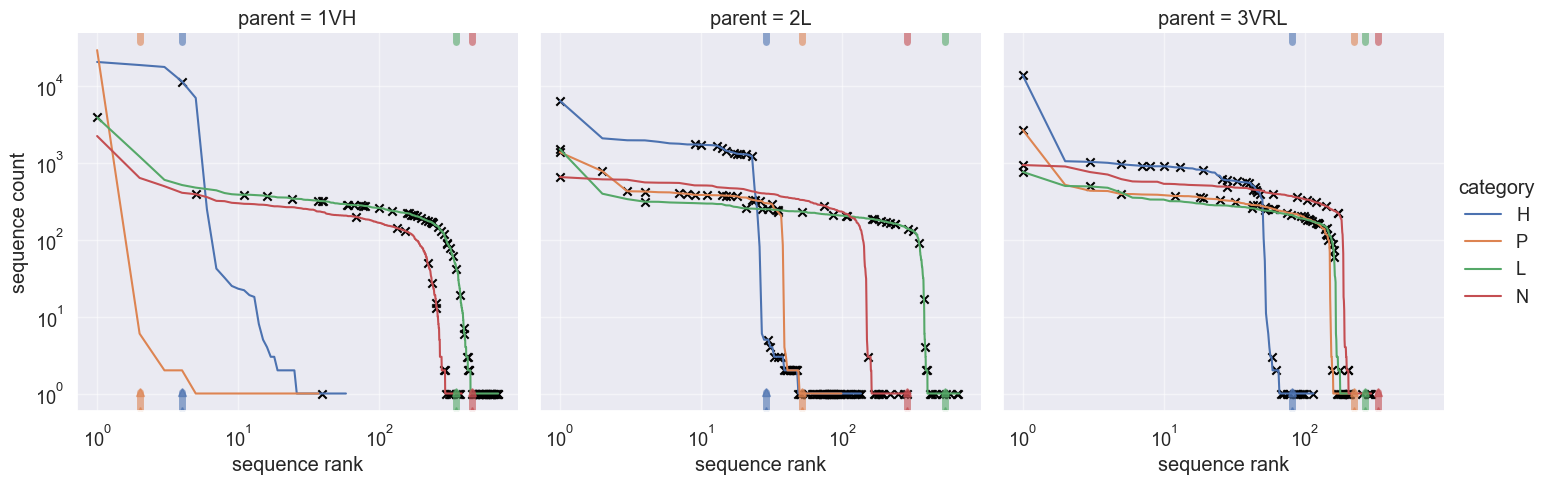

In [19]:
g = sns.relplot(data=all_seqs, x="seq_rank", y="dna_count", 
                col="parent", hue="category", kind="line")
g.set(xscale="log", yscale="log", 
       xlabel="sequence rank", ylabel="sequence count")

for parent, ax in g.axes_dict.items():
    samples_parent = samples_placed_df[samples_placed_df.parent == parent]
    for idx, row in samples_parent.iterrows():
        category = row.category
        #print(row.category, row.samples_placed)
        parent_locs = parent_locations_df[
                        (parent_locations_df.parent == parent) & 
                        (parent_locations_df.category == category)]
        if len(parent_locs):
            ax.scatter(parent_locs["seq_rank"], parent_locs["dna_count"],
                       marker="x", color="black")
        ax.axvline(row.num_placed, ymax=0.05, lw=5, alpha=0.6, marker="^", 
                   color=color_d[category])
        ax.axvline(row.num_placed, ymin=0.975, lw=5, alpha=0.6,  
                   color=color_d[category])        
g.savefig(figs_dir / "dna_sequences_recovered.png", dpi=300)
pass

In [20]:
# where we should place the horizontal cutoffs (dna_count)
# we do this by eyeballing the graph above to look for the steep dropoffs

# set them all to 100 first
samples_placed_df[["dna_cutoff"]] = 100

# set the ones that should be above 100
samples_placed_df.loc[
    (samples_placed_df.parent == "1VH") & 
    (samples_placed_df.category == "H"), "dna_cutoff"] = 10000
samples_placed_df.loc[
    (samples_placed_df.parent == "1VH") & 
    (samples_placed_df.category == "P"), "dna_cutoff"] = 10000

samples_placed_df.loc[
    (samples_placed_df.parent == "2L") & 
    (samples_placed_df.category == "H"), "dna_cutoff"] = 1000

In [21]:
# Look for parent amino acid sequences but sorted by dna counts
(all_seqs[all_seqs["ss_aa"] == "*0*"]
 .groupby(["parent", "category"])
 .head(3)
 .sort_values(by=["parent", "category"])
 .set_index(["parent", "category"])
)

ss_dna  dna_count  dna_dist  aa_dist  \
parent category                                                               
1VH    H                                  *0*      11321         0        0   
       H                                T558A          1         1        0   
       L                                  *0*       3876         0        0   
       L                                A432G        384         1        0   
       L                                T558C        368         1        0   
       N                                  *0*        389         0        0   
       N                          A285G,G375A        198         2        0   
       N                           A21G,T351C        141         2        0   
2L     H                                  *0*       6378         0        0   
       H                                T423C       1724         1        0   
       H              A219G,A441G,T456C,T783C       1716         4        0   
       P                                  *0*       1365         0        0   
       P                                 A75G        775         1        0   
       P                    T258C,T426C,G735C        425         3        0   
       L                                  *0*       1497         0        0   
       L                          A105G,A714G        311         2        0   
       L                                A207G        255         1        0   
       N                                  *0*        650         0        0   
       N                                A633G        276         1        0   
       N                          T135C,T318A          3         2        0   
3VRL   H                           T33C,C699G      13664         2        0   
       H                     T33C,T609C,C699G       1024         3        0   
       H         T33C,A264G,A444G,T528G,C699G        952         5        0   
       P                           T33C,C699G       2670         2        0   
       P                     T33C,C357A,C699G        391         3        0   
       P         T33C,T144A,C342T,A654G,C699G        369         5        0   
       L                           T33C,C699G        759         2        0   
       L                     T33C,C699G,T783A        491         3        0   
       L                     T33C,C699G,A729G        256         3        0   
       N                     T33C,C699G,C795A        932         3        0   
       N                     T33C,T138C,C699G        486         3        0   
       N                     T33C,A402G,C699G        446         3        0   

                ss_aa  early_stop  seq_rank  
parent category                              
1VH    H          *0*       False         4  
       H          *0*       False        39  
       L          *0*       False         1  
       L          *0*       False        11  
       L          *0*       False        16  
       N          *0*       False         5  
       N          *0*       False        68  
       N          *0*       False       134  
2L     H          *0*       False         1  
       H          *0*       False         9  
       H          *0*       False        10  
       P          *0*       False         1  
       P          *0*       False         2  
       P          *0*       False         3  
       L          *0*       False         1  
       L          *0*       False         4  
       L          *0*       False        21  
       N          *0*       False         1  
       N          *0*       False        74  
       N          *0*       False       152  
3VRL   H          *0*       False         1  
       H          *0*       False         3  
       H          *0*       False         5  
       P          *0*       False         1  
       P          *0*       False         5  
       P          *0*       False        12  
       L          *0*       False         1  
       L          

## Filter CCS sequences
* Keep only the top n seqs in each bin where n = number of sequences placed in each bin
* Keep sequences where the dna_count is above the steep dropoff in the graph above
* Keep sequences with dna_distance < 12
* Keep sequences that do not have an early termination codon when translated

Save the sequences that are left to a tsv file

In [22]:
def get_num_samples_placed(parent, category):
    return samples_placed_df.num_placed[
        (samples_placed_df["parent"] == parent) &
        (samples_placed_df["category"] == category)].item()

placed_cutoff_seqs = pd.concat(
            g.head(get_num_samples_placed(parent, category)) 
            for (parent, category), g in all_seqs.groupby(["parent", "category"])
)
placed_cutoff_seqs

,ss_dna,dna_count,dna_dist,aa_dist,ss_aa,early_stop,seq_rank,parent,category
0,"G43T,T454C,T594A",20356,3,3,"A15S,F152L,N198K",False,1,1VH,H
1,A679G,18573,1,1,K227E,False,2,1VH,H
2,"C17G,A178G,G257A",17532,3,3,"P6R,S60G,G86D",False,3,1VH,H
3,*0*,11321,0,0,*0*,False,4,1VH,H
0,"C71T,A565G",29019,2,2,"A24V,N189D",False,1,1VH,P
...,...,...,...,...,...,...,...,...,...
290,"T33C,A623T,T626A,C699G,C795A",1,5,2,"E208V,M209K",False,291,3VRL,N
291,"T33C,A623T,T626A,C699G,A731G",1,5,3,"E208V,M209K,N244S",False,292,3VRL,N
292,"T33C,A57G,A124T,T151A,T308A,A629G,C699G",1,7,4,"I42F,W51R,V103D,H210R",False,293,3VRL,N
293,"T33C,A563G,C699G,C740A",1,4,2,"D188G,A247D",False,294,3VRL,N


In [23]:
def get_dna_cutoff(parent, category):
    return samples_placed_df.dna_cutoff[
        (samples_placed_df["parent"] == parent) &
        (samples_placed_df["category"] == category)].item()

dna_cutoff_seqs = pd.concat(
            g[g.dna_count >= get_dna_cutoff(parent, category)]
            for (parent, category), g in placed_cutoff_seqs.groupby(["parent", "category"])
)
dna_cutoff_seqs

,ss_dna,dna_count,dna_dist,aa_dist,ss_aa,early_stop,seq_rank,parent,category
0,"G43T,T454C,T594A",20356,3,3,"A15S,F152L,N198K",False,1,1VH,H
1,A679G,18573,1,1,K227E,False,2,1VH,H
2,"C17G,A178G,G257A",17532,3,3,"P6R,S60G,G86D",False,3,1VH,H
3,*0*,11321,0,0,*0*,False,4,1VH,H
0,"C71T,A565G",29019,2,2,"A24V,N189D",False,1,1VH,P
...,...,...,...,...,...,...,...,...,...
180,"T33C,G382T,C699G",185,3,1,G128C,False,181,3VRL,N
181,"T33C,A200T,A444G,T551C,C699G",180,5,2,"H67L,I184T",False,182,3VRL,N
182,"T33C,A78G,C458T,A663T,C699G,C706T",148,6,2,"A153V,Q236*",True,183,3VRL,N
183,"T33C,T656C,C699G,C713T",125,4,2,"I219T,T238I",False,184,3VRL,N


/Users/brycejohnson/anaconda3/envs/rtl/lib/python3.9/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


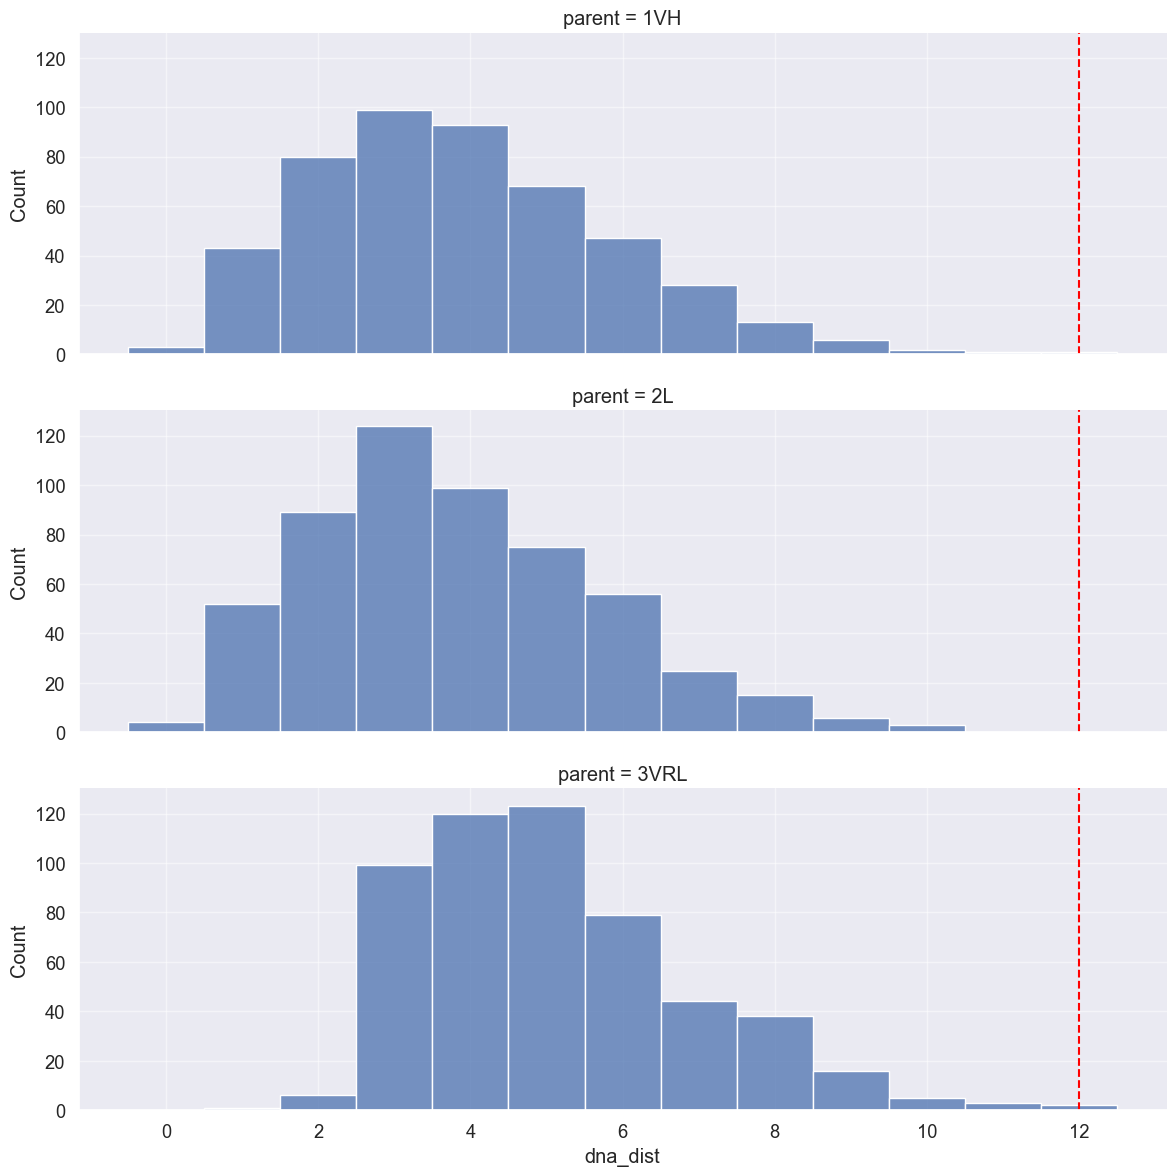

In [24]:
dna_distance_cutoff = 12

g = sns.displot(data=dna_cutoff_seqs, x="dna_dist", discrete=True, height=4, row="parent", aspect=3)

for _, ax in g.axes_dict.items():
    ax.axvline(dna_distance_cutoff, color="red", linestyle="--")

g.savefig(figs_dir / "dna_distance_cutoff.png", dpi=300)
pass

In [25]:
dist_cutoff_seqs = dna_cutoff_seqs[dna_cutoff_seqs.dna_dist < dna_distance_cutoff]
dist_cutoff_seqs

,ss_dna,dna_count,dna_dist,aa_dist,ss_aa,early_stop,seq_rank,parent,category
0,"G43T,T454C,T594A",20356,3,3,"A15S,F152L,N198K",False,1,1VH,H
1,A679G,18573,1,1,K227E,False,2,1VH,H
2,"C17G,A178G,G257A",17532,3,3,"P6R,S60G,G86D",False,3,1VH,H
3,*0*,11321,0,0,*0*,False,4,1VH,H
0,"C71T,A565G",29019,2,2,"A24V,N189D",False,1,1VH,P
...,...,...,...,...,...,...,...,...,...
180,"T33C,G382T,C699G",185,3,1,G128C,False,181,3VRL,N
181,"T33C,A200T,A444G,T551C,C699G",180,5,2,"H67L,I184T",False,182,3VRL,N
182,"T33C,A78G,C458T,A663T,C699G,C706T",148,6,2,"A153V,Q236*",True,183,3VRL,N
183,"T33C,T656C,C699G,C713T",125,4,2,"I219T,T238I",False,184,3VRL,N


/Users/brycejohnson/anaconda3/envs/rtl/lib/python3.9/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


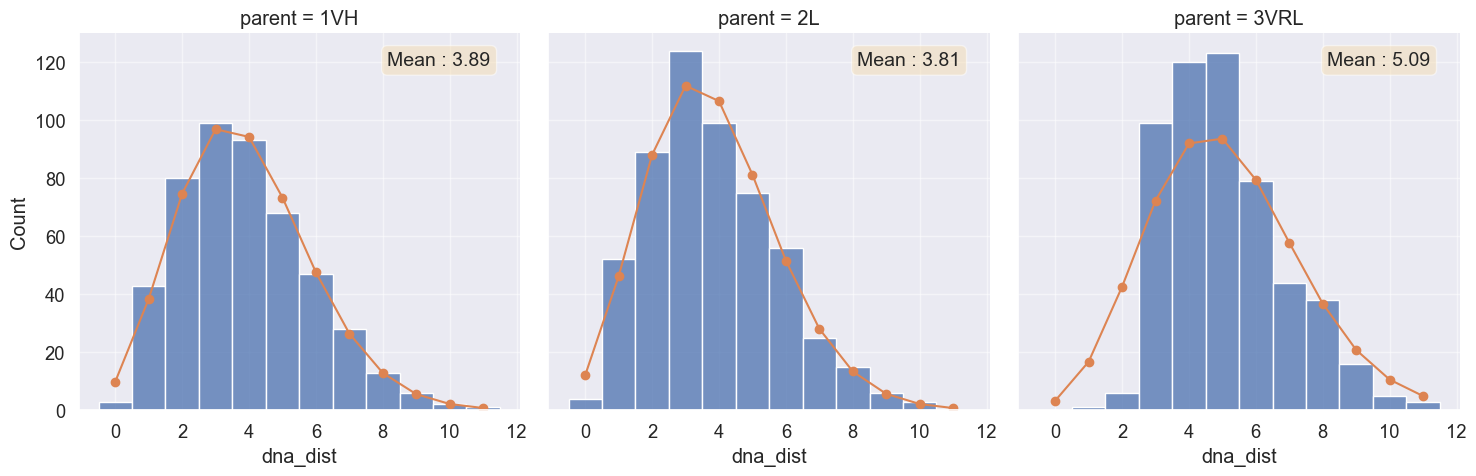

In [26]:
g = sns.displot(data=dist_cutoff_seqs,
                x="dna_dist", col="parent", discrete=True)

for parent, ax in g.axes_dict.items():
    mask = (dist_cutoff_seqs["parent"] == parent)
    dna_dists = dist_cutoff_seqs["dna_dist"][mask]
    N = len(dna_dists)
    p_mean = dna_dists.mean()
    x_vals = np.arange(0, int(ax.get_xlim()[1]))
    poisson_estimates = poisson.pmf(x_vals, p_mean) * N
    ax.plot(x_vals, poisson_estimates, "o-", color=sns.color_palette()[1])
    
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    textstr = f"Mean : {p_mean:.2f}"
    ax.text(0.70, 0.95, textstr, transform=ax.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
    
    
g.savefig(figs_dir / "mutation_distribution.png", dpi=300)

pass

In [27]:
def extract_mutation_positions(s):
    """Takes a string of mutants  and returns the positions
        that were mutated. e.g. s=C71T,A565G ret=[71, 565]
        Special handling "*0*" return None
    """
    ret = None
    if s != "*0*":
        ret = [int(m[1:-1]) for m in s.split(",")]
    return ret

ret = extract_mutation_positions("*0*")
assert(ret is None)
ret = extract_mutation_positions("C71T,A565G")
assert(ret == [71, 565])

In [28]:
def make_mut_postions_into_df(row):
    positions = extract_mutation_positions(row.ss_dna)
    ret = None
    if positions is not None:
        ret = pd.DataFrame(positions)
        ret.columns=["mut_positions"]
        ret["parent"] = row.parent
        ret["category"] = row.category
        ret["seq_rank"] = row.seq_rank
    return ret

#mut_positions_df = [make_mut_postions_into_df(row) 
#               in dist_cutoff_seqs.itertuples(index=False)]

all_mut_positions = []
for row in dist_cutoff_seqs.itertuples(index=False):
    x = make_mut_postions_into_df(row)
    all_mut_positions.append(x)

all_mut_positions_df = pd.concat(all_mut_positions)
all_mut_positions_df.head()

,mut_positions,parent,category,seq_rank
0,43,1VH,H,1
1,454,1VH,H,1
2,594,1VH,H,1
0,679,1VH,H,2
0,17,1VH,H,3


/Users/brycejohnson/anaconda3/envs/rtl/lib/python3.9/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


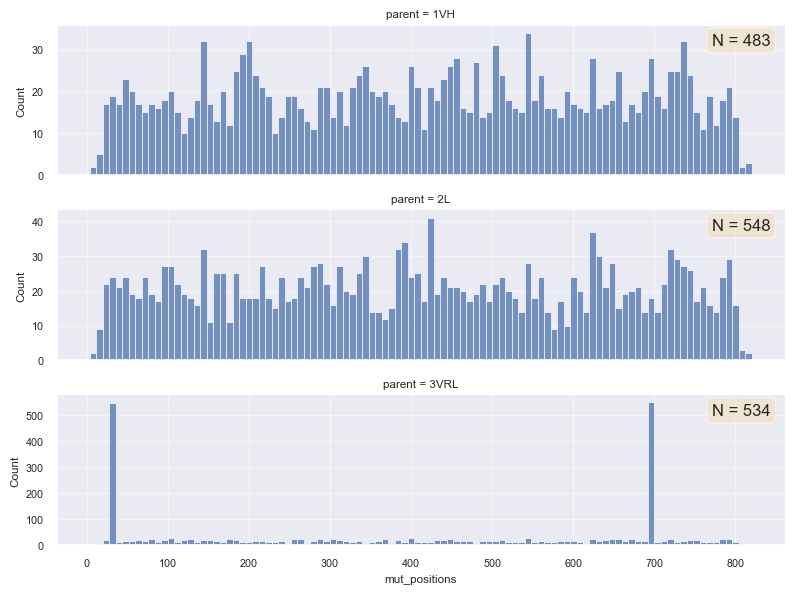

In [29]:
sns.set(font_scale=0.7)
g = sns.displot(data=all_mut_positions_df, x="mut_positions", row="parent", 
            height=2, aspect=4, facet_kws=dict(sharey=False), binwidth=8)

for parent, ax in g.axes_dict.items():
    mask = (dist_cutoff_seqs["parent"] == parent)
    N = mask.sum()
    
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    textstr = f"N = {N}"
    ax.text(0.90, 0.95, textstr, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=props)
    
g.savefig(figs_dir / "mutation_position_distribution.png", dpi=300)

pass

/Users/brycejohnson/anaconda3/envs/rtl/lib/python3.9/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


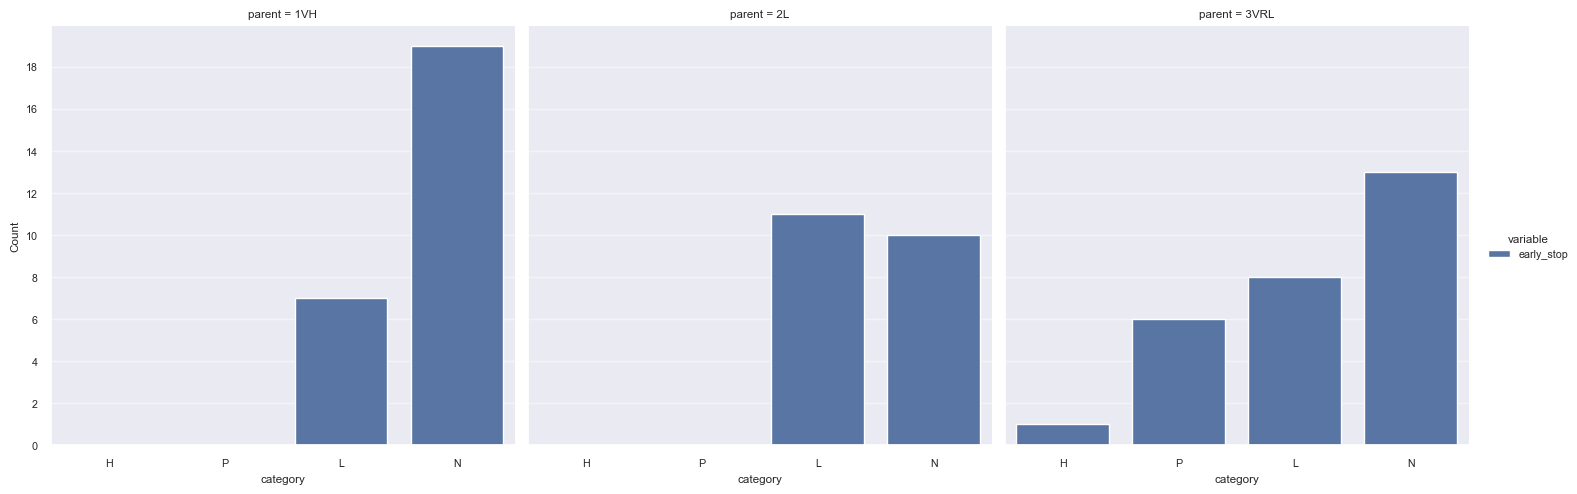

In [30]:
early_stop_counts_df = dist_cutoff_seqs.groupby(["parent", "category"])["early_stop"].agg(sum)

g = sns.catplot(data=pd.melt(early_stop_counts_df.reset_index(), ["parent", "category"]), 
                x="category", y="value", hue="variable",
            col="parent", kind="bar")

ax = g.axes[0, 0]
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_ylabel("Count")

g.savefig(figs_dir / "stops_distribution.png", dpi=300)

pass

In [31]:
no_truncated_seqs = dist_cutoff_seqs[~dist_cutoff_seqs.early_stop]
no_truncated_seqs

,ss_dna,dna_count,dna_dist,aa_dist,ss_aa,early_stop,seq_rank,parent,category
0,"G43T,T454C,T594A",20356,3,3,"A15S,F152L,N198K",False,1,1VH,H
1,A679G,18573,1,1,K227E,False,2,1VH,H
2,"C17G,A178G,G257A",17532,3,3,"P6R,S60G,G86D",False,3,1VH,H
3,*0*,11321,0,0,*0*,False,4,1VH,H
0,"C71T,A565G",29019,2,2,"A24V,N189D",False,1,1VH,P
...,...,...,...,...,...,...,...,...,...
179,"T33C,A263T,A491T,G690A,C699G",187,5,2,"K88I,D164V",False,180,3VRL,N
180,"T33C,G382T,C699G",185,3,1,G128C,False,181,3VRL,N
181,"T33C,A200T,A444G,T551C,C699G",180,5,2,"H67L,I184T",False,182,3VRL,N
183,"T33C,T656C,C699G,C713T",125,4,2,"I219T,T238I",False,184,3VRL,N


In [32]:
no_truncated_seqs.to_csv("../../data/sequences_Oct22.tsv", sep="\t", index=False)

In [33]:
# with pd.option_context('display.max_rows', None):
#     display(no_truncated_seqs.drop("early_stop", axis="columns"))

In [34]:
final_filtered_seqs = no_truncated_seqs

In [35]:
samples_placed_recovered_df = pd.merge(
     samples_placed_df.drop(columns="dna_cutoff") ,
    final_filtered_seqs.groupby(["parent", "category"]).agg(     
        samples_recovered = ('ss_dna', len),
        ).reset_index())

samples_placed_recovered_df.set_index(["parent", "category"])

num_placed  samples_recovered
parent category                               
1VH    H                  4                  4
       P                  2                  1
       L                349                291
       N                454                161
2L     H                 29                 23
       P                 52                 37
       L                532                337
       N                287                130
3VRL   H                 81                 50
       P                222                139
       L                266                146
       N                330                171

/Users/brycejohnson/anaconda3/envs/rtl/lib/python3.9/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


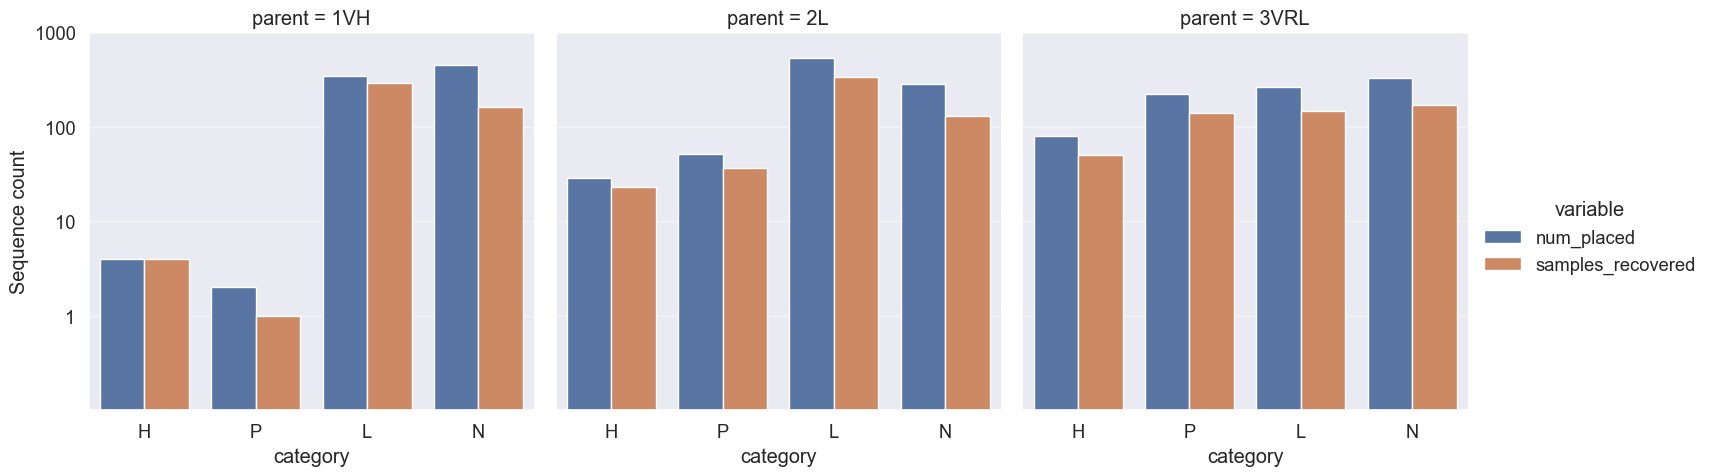

In [36]:
sns.set(font_scale=1.2)

g = sns.catplot(data=pd.melt(samples_placed_recovered_df, ["parent", "category"]), 
                x="category", y="value", hue="variable",
            col="parent", kind="bar")

ticks = [0.1, 1, 10, 100, 1000]
ticklabels = list(map(str, ticks))
ticklabels[0] = " "
g.set(yscale="log", yticks=ticks, yticklabels=ticklabels)
g.axes[0, 0].set_ylabel("Sequence count")

g.savefig(figs_dir / "sequences_placed_vs_recovered.png", dpi=300)

pass

/Users/brycejohnson/anaconda3/envs/rtl/lib/python3.9/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


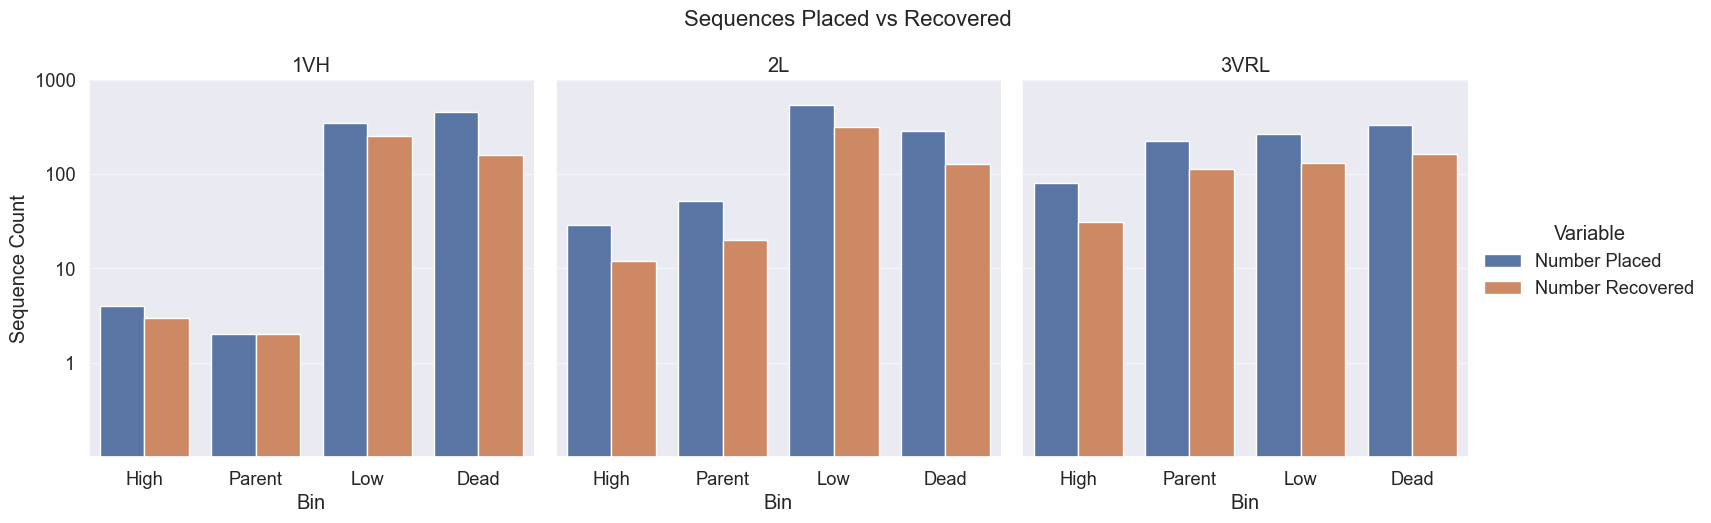

In [37]:

# true samples recovered there was a previous step where sequences were filtered.  ....
final_filtered_seqs = pd.read_csv("../../output/ordinal_Oct22_sequences_with_dca_score.csv")

samples_placed_recovered_df = pd.merge(
    samples_placed_df.drop(columns="dna_cutoff"),
    final_filtered_seqs.groupby(["parent", "category"]).agg(
        samples_recovered=('sequence_aa_trim', 'count'),
    ).reset_index(),
    on=["parent", "category"],
    how="left",
)
samples_placed_recovered_df["samples_recovered"] = samples_placed_recovered_df["samples_recovered"].fillna(0)

# Clean up bin labels
bin_map = {"H": "High", "P": "Parent", "L": "Low", "N": "Dead"}
samples_placed_recovered_df["Bin"] = samples_placed_recovered_df["category"].map(bin_map)

melted = pd.melt(samples_placed_recovered_df, ["parent", "Bin"],
                  value_vars=["num_placed", "samples_recovered"])

# Clean up legend labels
var_map = {
    "num_placed": "Number Placed",
    "samples_recovered": "Number Recovered",
}
melted["Variable"] = melted["variable"].map(var_map).fillna(melted["variable"])

sns.set(font_scale=1.2)
g = sns.catplot(data=melted, x="Bin", y="value", hue="Variable",
                col="parent", kind="bar")

ticks = [0.1, 1, 10, 100, 1000]
ticklabels = list(map(str, ticks))
ticklabels[0] = " "
g.set(yscale="log", yticks=ticks, yticklabels=ticklabels)
g.set_axis_labels("Bin", "Sequence Count")
g.set_titles("{col_name}")
g.fig.suptitle("Sequences Placed vs Recovered", size=16, y=1.05)

g.savefig(figs_dir / "sequences_placed_vs_recovered.png", dpi=300, bbox_inches="tight")

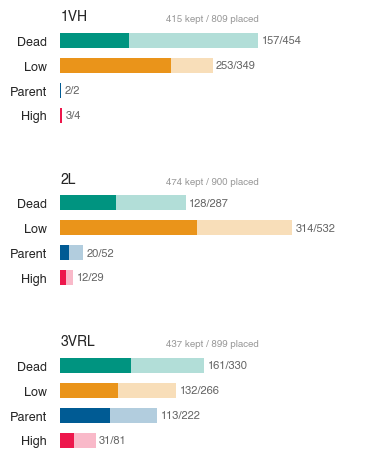

In [38]:
# ── Placed vs Kept: horizontal overlaid bars ──────────────────────────────
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams["figure.facecolor"] = "white"
matplotlib.rcParams["axes.facecolor"]   = "white"
matplotlib.rcParams["svg.fonttype"]     = "none"
matplotlib.rcParams["font.family"]      = "sans-serif"
matplotlib.rcParams["font.sans-serif"]  = ["Helvetica", "Arial", "DejaVu Sans"]

bin_map   = {"N": "Dead", "L": "Low", "P": "Parent", "H": "High"}
bin_order = ["Dead", "Low", "Parent", "High"]
lib_order = ["1VH", "2L", "3VRL"]
bin_colors = {
    "High":   "#ED174C",
    "Parent": "#005B94",
    "Low":    "#EA941A",
    "Dead":   "#009480",
}
ALPHA_KEPT, ALPHA_PLACED = 1.0, 0.30

placed, kept = {}, {}
for lib in lib_order:
    placed[lib], kept[lib] = {}, {}
    for b_short, b in bin_map.items():
        row = samples_placed_recovered_df[
            (samples_placed_recovered_df["parent"] == lib) &
            (samples_placed_recovered_df["category"] == b_short)
        ]
        placed[lib][b] = int(row["num_placed"].values[0]) if len(row) else 0
        kept[lib][b]   = int(row["samples_recovered"].values[0]) if len(row) else 0

max_val = max(placed[lib][b] for lib in lib_order for b in bin_order)

fig, axes = plt.subplots(3, 1, figsize=(4.5, 5.5), sharex=True,
                         gridspec_kw={"hspace": 0.65,
                                      "left": 0.18,
                                      "right": 0.85})

for ax, lib in zip(axes, lib_order):
    for i, b in enumerate(bin_order):
        p, k = placed[lib][b], kept[lib][b]
        ax.barh(i, p, height=0.6, color=bin_colors[b], alpha=ALPHA_PLACED, edgecolor="none")
        ax.barh(i, k, height=0.6, color=bin_colors[b], alpha=ALPHA_KEPT, edgecolor="none")
        ax.text(max(p, k) + 8, i, f"{k}/{p}",
                va="center", ha="left", fontsize=8, color="#666")

    ax.set_yticks(range(4))
    ax.set_yticklabels(bin_order, fontsize=9, fontweight="medium")
    ax.invert_yaxis()

    ax.set_title(lib, loc="left", fontsize=10, fontweight="semibold", pad=6)
    ax.text(0.35, 1.05, f"{sum(kept[lib].values())} kept / {sum(placed[lib].values())} placed",
            transform=ax.transAxes, ha="left", va="bottom",
            fontsize=7, color="#999", style="italic")

    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(left=False, bottom=False)
    ax.set_xlim(0, max_val * 1.30)
    ax.xaxis.set_visible(False)

plt.savefig(figs_dir / "placed_vs_kept.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.savefig(figs_dir / "placed_vs_kept.svg", bbox_inches="tight", facecolor="white")
plt.show()

In [39]:
samples_placed_recovered_df

,parent,category,num_placed,samples_recovered,Bin
0,1VH,H,4,3,High
1,1VH,P,2,2,Parent
2,1VH,L,349,253,Low
3,1VH,N,454,157,Dead
4,2L,H,29,12,High
5,2L,P,52,20,Parent
6,2L,L,532,314,Low
7,2L,N,287,128,Dead
8,3VRL,H,81,31,High
9,3VRL,P,222,113,Parent


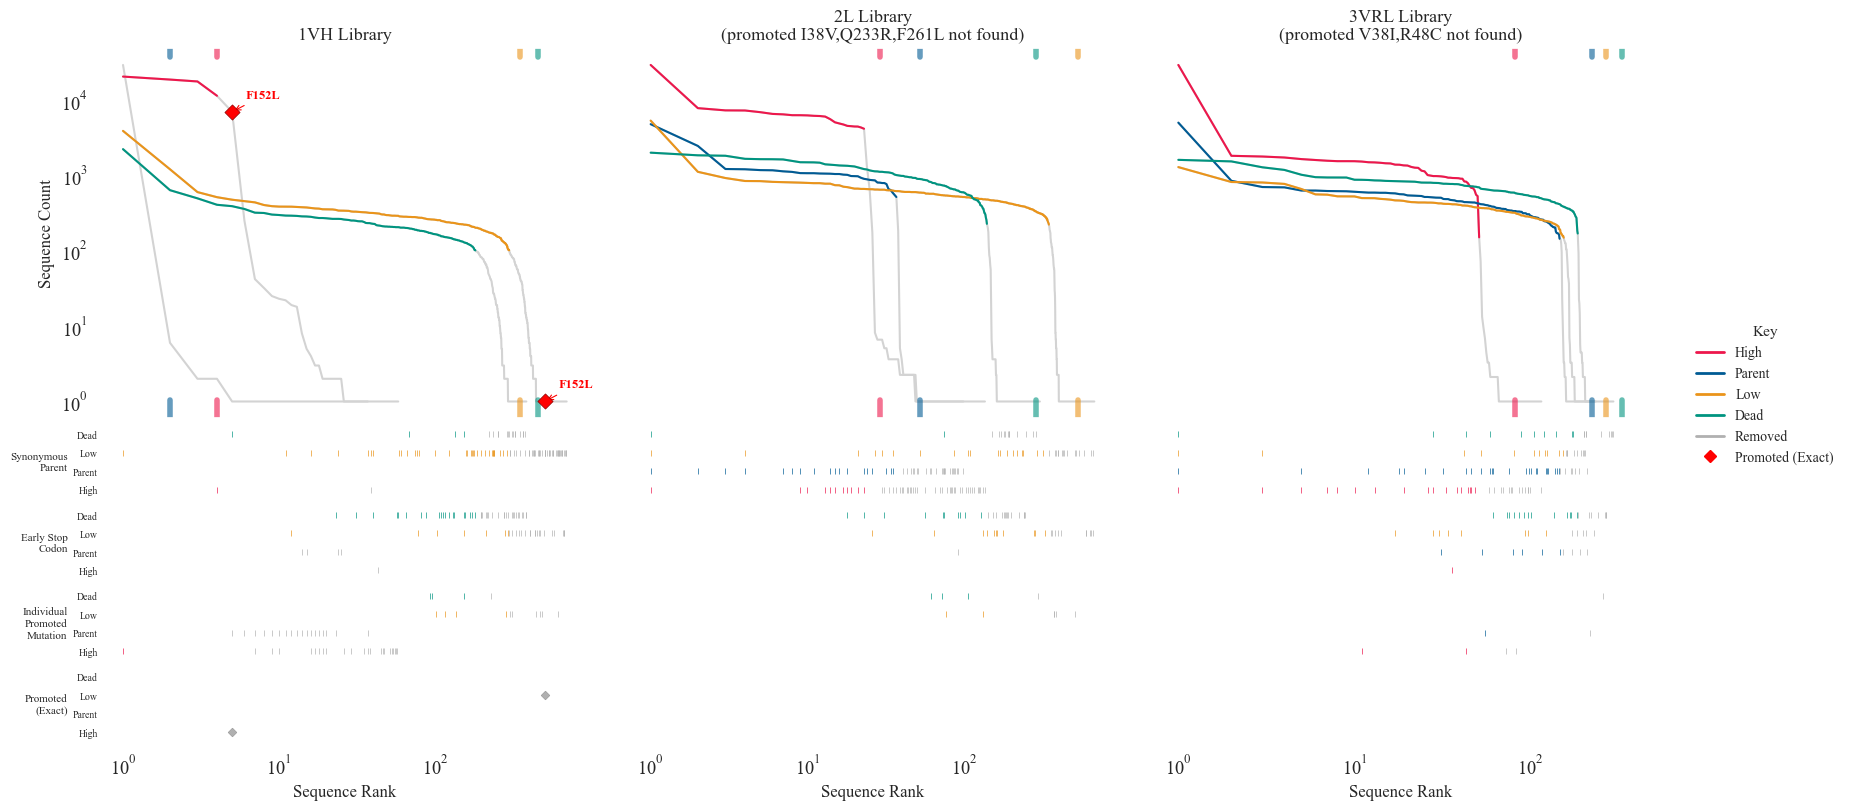

In [43]:
import matplotlib
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

matplotlib.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'axes.grid': False,
})
color_d = {
    "H": "#ED174C",
    "P": "#005B94",
    "L": "#EA941A",
    "N": "#009480",
}
promoted_mutations = {
    "1VH": "F152L",
    "2L": "I38V,Q233R,F261L",
    "3VRL": "V38I,R48C",
}

category_labels = {"H": "High", "P": "Parent", "L": "Low", "N": "Dead"}
categories = ["H", "P", "L", "N"]
parents = ["1VH", "2L", "3VRL"]

parent_locations_df = all_seqs[all_seqs["ss_aa"] == "*0*"]
early_stop_df = all_seqs[all_seqs["early_stop"] == True]

track_labels = ["Synonymous\nParent", "Early Stop\nCodon",
                "Individual\nPromoted\nMutation", "Promoted\n(Exact)"]
n_tracks = len(track_labels)

GREY_REMOVED = '#b0b0b0'
GRID_COLOR = 'white'

fig = plt.figure(figsize=(22, 9))
outer_gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1, 0.25], wspace=0.10)

for pi in range(len(parents)):
    parent = parents[pi]
    inner_gs = outer_gs[0, pi].subgridspec(
        n_tracks + 1, 1, height_ratios=[5] + [1] * n_tracks, hspace=0.05)

    ax_main = fig.add_subplot(inner_gs[0])
    ax_main.set_axisbelow(True)
    ax_main.grid(True, which='major', axis='both',
                 color=GRID_COLOR, linewidth=0.8, zorder=0)

    track_axes = [fig.add_subplot(inner_gs[i + 1], sharex=ax_main) for i in range(n_tracks)]

    for ti in range(n_tracks):
        ta = track_axes[ti]
        ta.set_ylim(-0.5, 3.5)
        ta.set_xscale("log")
        if pi == 0:
            ta.set_yticks([0, 1, 2, 3])
            ta.set_yticklabels(["High", "Parent", "Low", "Dead"], fontsize=7)
            ta.tick_params(axis='y', length=0, pad=2)
            ta.set_ylabel(track_labels[ti], fontsize=8,
                         rotation=0, ha='right', va='center')
        else:
            ta.set_yticks([])
            ta.tick_params(axis='y', length=0)
        if ti < n_tracks - 1:
            ta.tick_params(labelbottom=False)
        else:
            ta.set_xlabel("Sequence Rank")

        # vertical gridlines aligned with the main plot's x-ticks — BEHIND markers
        ta.set_axisbelow(True)
        ta.grid(True, which='major', axis='x',
                color=GRID_COLOR, linewidth=0.8, zorder=0)

        # horizontal reference lines per category row — BEHIND markers (zorder=0)
        for y in (0, 1, 2, 3):
            ta.axhline(y, color=GRID_COLOR, linewidth=0.8, zorder=0)

    samples_parent = samples_placed_df[samples_placed_df.parent == parent]
    promoted_str = promoted_mutations[parent]
    individual_muts = promoted_str.split(",")

    cutoffs = {}
    for _, r in samples_parent.iterrows():
        cutoffs[r.category] = (r.num_placed, r.dna_cutoff)

    def check_kept(seq_rank, dna_count, category, _c=cutoffs):
        if category not in _c:
            return False
        np_, dc = _c[category]
        return (seq_rank <= np_) and (dna_count >= dc)

    # --- main plot ---
    ax_main.set_xscale("log")
    ax_main.set_yscale("log")
    if pi == 0:
        ax_main.set_ylabel("Sequence Count")
    else:
        ax_main.tick_params(labelleft=False)
    ax_main.tick_params(labelbottom=False)

    exact = all_seqs[(all_seqs['parent'] == parent) &
                      (all_seqs['ss_aa'] == promoted_str)]
    if len(exact):
        ax_main.set_title(f"{parent} Library")
    else:
        ax_main.set_title(f"{parent} Library\n(promoted {promoted_str} not found)")

    for category in categories:
        data = all_seqs[(all_seqs['parent'] == parent) &
                        (all_seqs['category'] == category)].sort_values('seq_rank')
        if len(data) == 0:
            continue

        num_placed, dna_cutoff = cutoffs[category]
        color = color_d[category]

        kept_mask = ((data['seq_rank'] <= num_placed) &
                     (data['dna_count'] >= dna_cutoff))

        ax_main.plot(data['seq_rank'], data['dna_count'],
                     color='lightgrey', linewidth=1.5, zorder=1)

        kept = data[kept_mask]
        if len(kept):
            ax_main.plot(kept['seq_rank'], kept['dna_count'],
                         color=color, linewidth=1.5, zorder=2)

        ax_main.axvline(num_placed, ymax=0.05, lw=4, alpha=0.6, color=color)
        ax_main.axvline(num_placed, ymin=0.975, lw=4, alpha=0.6, color=color)

    if len(exact):
        ax_main.scatter(exact["seq_rank"], exact["dna_count"],
                        marker="D", color="red", zorder=7, s=60,
                        edgecolors='darkred', linewidths=0.5)
        for _, hit in exact.iterrows():
            ax_main.annotate(promoted_str,
                             xy=(hit['seq_rank'], hit['dna_count']),
                             xytext=(10, 10), textcoords='offset points',
                             fontsize=9, fontweight='bold', color='red',
                             arrowprops=dict(arrowstyle='->', color='red', lw=0.8))

    # --- track 0: synonymous parent ---
    for ci, category in enumerate(categories):
        cat_df = parent_locations_df[
            (parent_locations_df.parent == parent) &
            (parent_locations_df.category == category)]
        if len(cat_df) == 0:
            continue
        color = color_d[category]
        for _, row in cat_df.iterrows():
            c = color if check_kept(row['seq_rank'], row['dna_count'], category) else GREY_REMOVED
            track_axes[0].scatter(row["seq_rank"], ci, marker="|", color=c,
                                  s=15, linewidths=0.6, alpha=0.8,
                                  zorder=3 if c != GREY_REMOVED else 1)

    # --- track 1: early stop codons ---
    for ci, category in enumerate(categories):
        cat_df = early_stop_df[
            (early_stop_df.parent == parent) &
            (early_stop_df.category == category)]
        if len(cat_df) == 0:
            continue
        color = color_d[category]
        for _, row in cat_df.iterrows():
            c = color if check_kept(row['seq_rank'], row['dna_count'], category) else GREY_REMOVED
            track_axes[1].scatter(row["seq_rank"], ci, marker="|", color=c,
                                  s=15, linewidths=0.6, alpha=0.8,
                                  zorder=3 if c != GREY_REMOVED else 1)

    # --- track 2: individual promoted mutations ---
    for ci, category in enumerate(categories):
        for mut in individual_muts:
            partial = all_seqs[
                (all_seqs['parent'] == parent) &
                (all_seqs['category'] == category) &
                (all_seqs['ss_aa'].str.contains(
                    r'(?:^|,)' + mut + r'(?:,|$)', regex=True)) &
                (all_seqs['ss_aa'] != promoted_str) &
                (all_seqs['ss_aa'] != '*0*')]
            if len(partial) == 0:
                continue
            color = color_d[category]
            for _, row in partial.iterrows():
                c = color if check_kept(row['seq_rank'], row['dna_count'], category) else GREY_REMOVED
                track_axes[2].scatter(row["seq_rank"], ci, marker="|", color=c,
                                      s=15, linewidths=0.6, alpha=0.8,
                                      zorder=3 if c != GREY_REMOVED else 1)

    # # --- track 3: promoted exact ---
    for ci, category in enumerate(categories):
        ex = all_seqs[
            (all_seqs['parent'] == parent) &
            (all_seqs['category'] == category) &
            (all_seqs['ss_aa'] == promoted_str)]
        if len(ex) == 0:
            continue
        color = color_d[category]
        for _, row in ex.iterrows():
            c = color if check_kept(row['seq_rank'], row['dna_count'], category) else GREY_REMOVED
            track_axes[3].scatter(row["seq_rank"], ci, marker="D", color=c,
                                  s=20, edgecolors='darkred' if c != GREY_REMOVED else 'grey',
                                  linewidths=0.3,
                                  zorder=3 if c != GREY_REMOVED else 1)

# legend
legend_ax = fig.add_subplot(outer_gs[0, 3])
legend_ax.axis('off')

legend_handles = [Line2D([0], [0], color=color_d[c], lw=2,
                          label=category_labels[c])
                  for c in categories]
legend_handles.append(Line2D([0], [0], color=GREY_REMOVED, lw=2,
                              label='Removed'))
legend_handles.append(Line2D([0], [0], marker='D', color='red', lw=0,
                              markersize=6, label='Promoted (Exact)'))

legend_ax.legend(handles=legend_handles, title="Key",
                 loc='center left', frameon=False, fontsize=10,
                 title_fontsize=11)

fig.savefig(figs_dir / "dna_sequences_recovered.png", dpi=300, bbox_inches='tight')

fig.savefig(figs_dir / "dna_sequences_recovered.svg", dpi=300, bbox_inches='tight')



findfont: Generic family 'serif' not found because none of the following families were found: sans-serif
findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'serif' not found because none of the following families were found: sans-serif
findfont: Generic family 'serif' not found because none of the following families were found: sans-serif
findfont: Generic family 'serif' not found because none of the following families were found: sans-serif
findfont: Generic family 'serif' not found because none of the following families were found: sans-serif
findfont: Generic family 'serif' not found because none of the following families were found: sans-serif
findfont: Generic family 'serif' not found because none of the following families were found: sans-serif
findfont: Generic family 'serif' not found because none of the following families were found: sans-serif
findfont: Generic family 'serif' not found because none of the following families were f

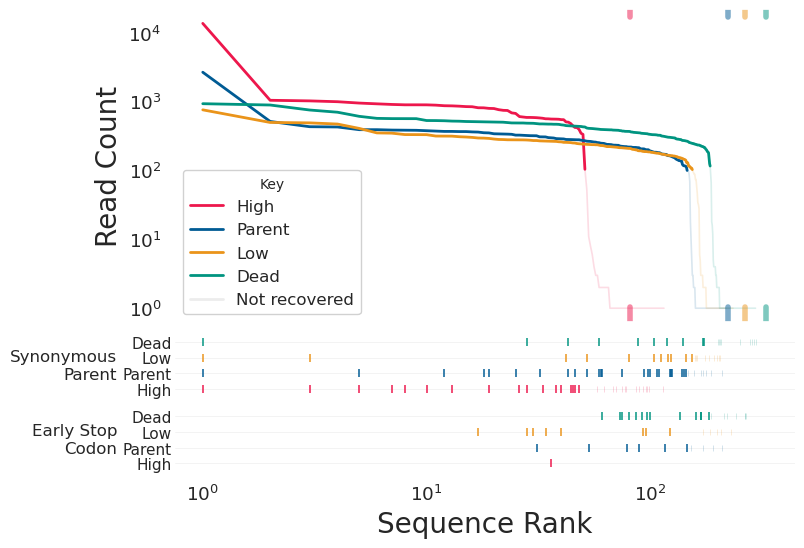

In [41]:
# ── 3VRL rank-abundance with parent & stop codon tracks ───────────────────
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

matplotlib.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['sans-serif'],
    'font.size': 25,
    'axes.labelsize': 20,
    'axes.titlesize': 20,
    'axes.grid': False,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'svg.fonttype': 'none',
    'font.sans-serif': ["Helvetica", "Arial", "DejaVu Sans"]
})


color_d = {
    "H": "#ED174C",
    "P": "#005B94",
    "L": "#EA941A",
    "N": "#009480",
}
parent = "3VRL"
categories = ["H", "P", "L", "N"]
category_labels = {"H": "High", "P": "Parent", "L": "Low", "N": "Dead"}

track_labels = ["Synonymous\nParent", "Early Stop\nCodon"]
n_tracks = len(track_labels)

parent_locations_df = all_seqs[all_seqs["ss_aa"] == "*0*"]
early_stop_df = all_seqs[all_seqs["early_stop"] == True]

samples_parent = samples_placed_df[samples_placed_df.parent == parent]
cutoffs = {}
for _, r in samples_parent.iterrows():
    cutoffs[r.category] = (r.num_placed, r.dna_cutoff)

def check_kept(seq_rank, dna_count, category):
    if category not in cutoffs:
        return False
    np_, dc = cutoffs[category]
    return (seq_rank <= np_) and (dna_count >= dc)

# ── Layout ────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(8, 6))
gs = fig.add_gridspec(n_tracks + 1, 1, height_ratios=[5] + [1] * n_tracks, hspace=0.08)

ax_main = fig.add_subplot(gs[0])
track_axes = [fig.add_subplot(gs[i + 1], sharex=ax_main) for i in range(n_tracks)]

# ── Main rank-abundance curve ─────────────────────────────────────────────
ax_main.set_xscale("log")
ax_main.set_yscale("log")
ax_main.set_ylabel("Read Count")
ax_main.tick_params(labelbottom=False)
# ax_main.set_title("3VRL Library", fontsize=13, fontweight="600")

for category in categories:
    data = all_seqs[(all_seqs['parent'] == parent) &
                    (all_seqs['category'] == category)].sort_values('seq_rank')
    if len(data) == 0:
        continue

    num_placed, dna_cutoff = cutoffs[category]
    color = color_d[category]
    kept_mask = (data['seq_rank'] <= num_placed) & (data['dna_count'] >= dna_cutoff)

    # Full curve — faded version of bin color
    ax_main.plot(data['seq_rank'], data['dna_count'],
                 color=color, alpha=0.15, linewidth=1.2, zorder=1)

    # Kept portion — full color
    kept_data = data[kept_mask]
    if len(kept_data):
        ax_main.plot(kept_data['seq_rank'], kept_data['dna_count'],
                     color=color, linewidth=2, zorder=2)

    # Cutoff tick marks
    ax_main.axvline(num_placed, ymax=0.05, lw=4, alpha=0.5, color=color)
    ax_main.axvline(num_placed, ymin=0.975, lw=4, alpha=0.5, color=color)

# ── Configure track axes ──────────────────────────────────────────────────
for ti, ta in enumerate(track_axes):
    ta.set_ylim(-0.5, 3.5)
    ta.set_xscale("log")
    ta.set_yticks([0, 1, 2, 3])
    ta.set_yticklabels(["High", "Parent", "Low", "Dead"], fontsize=11)
    ta.tick_params(axis='y', length=0, pad=2)
    ta.set_ylabel(track_labels[ti], fontsize=12, rotation=0, ha='right', va='center')

    for y in (0, 1, 2, 3):
        ta.axhline(y, color='#eee', linewidth=0.5, zorder=0)

    if ti < n_tracks - 1:
        ta.tick_params(labelbottom=False)
    else:
        ta.set_xlabel("Sequence Rank")

    for spine in ta.spines.values():
        spine.set_visible(False)

# ── Track 0: synonymous parent ────────────────────────────────────────────
for ci, category in enumerate(categories):
    cat_df = parent_locations_df[
        (parent_locations_df.parent == parent) &
        (parent_locations_df.category == category)]
    if len(cat_df) == 0:
        continue
    color = color_d[category]
    for _, row in cat_df.iterrows():
        is_kept = check_kept(row['seq_rank'], row['dna_count'], category)
        if is_kept:
            track_axes[0].scatter(row["seq_rank"], ci, marker="|", color=color,
                                  s=40, linewidths=1.2, alpha=0.9, zorder=3)
        else:
            track_axes[0].scatter(row["seq_rank"], ci, marker="|", color=color,
                                  s=25, linewidths=0.6, alpha=0.2, zorder=1)

# ── Track 1: early stop codons ────────────────────────────────────────────
for ci, category in enumerate(categories):
    cat_df = early_stop_df[
        (early_stop_df.parent == parent) &
        (early_stop_df.category == category)]
    if len(cat_df) == 0:
        continue
    color = color_d[category]
    for _, row in cat_df.iterrows():
        is_kept = check_kept(row['seq_rank'], row['dna_count'], category)
        if is_kept:
            track_axes[1].scatter(row["seq_rank"], ci, marker="|", color=color,
                                  s=40, linewidths=1.2, alpha=0.9, zorder=3)
        else:
            track_axes[1].scatter(row["seq_rank"], ci, marker="|", color=color,
                                  s=25, linewidths=0.6, alpha=0.2, zorder=1)

# ── Legend ────────────────────────────────────────────────────────────────
legend_handles = [Line2D([0], [0], color=color_d[c], lw=2, label=category_labels[c])
                  for c in categories]
legend_handles.append(Line2D([0], [0], color='grey', lw=2, alpha=0.15, label='Not recovered'))

ax_main.legend(handles=legend_handles, title="Key", loc='lower left',
               frameon=True, framealpha=0.9, fontsize=12, title_fontsize=10)

fig.savefig(figs_dir / "3vrl_rank_abundance.png", dpi=300, bbox_inches='tight')
fig.savefig(figs_dir / "3vrl_rank_abundance.svg", bbox_inches='tight')
plt.show()

In [42]:
# Check actual row count per group, not just nunique
# Find DNA sequences (not just parent) that show up in multiple bins/categories
# within the same library — this is the noise signal you're worried about.

dup_check = (
    all_seqs
    .groupby(["parent", "ss_aa"], observed=True)["category"]
    .nunique(dropna=False)
    .reset_index(name="n_bins")
)

cross_bin_dna = dup_check[dup_check["n_bins"] > 1]

cross_bin_dna

,parent,ss_aa,n_bins
0,1VH,*0*,3
18,1VH,"A15S,F152L,N198K",2
53,1VH,"A24V,N189D",2
196,1VH,"D49Y,F152I,W196C,A247V",2
336,1VH,F152L,2
348,1VH,F261L,2
373,1VH,F62S,2
465,1VH,"H68L,D164V,W196C,H246R",2
520,1VH,I42L,2
585,1VH,L125P,2
